
# HPO por perfiles de riesgo + finalistas + 100k

Este notebook está organizado en **4 fases muy claras**:

## Fase 0. Definición de perfiles de riesgo
Se fija un valor representativo para cada perfil:

- **muy conservador** → `0.10`
- **conservador** → `0.30`
- **normal** → `0.50`
- **arriesgado** → `0.70`
- **muy arriesgado** → `0.90`

## Fase 1. Grid reducido por perfil
Para **cada perfil de riesgo** se ejecutan **todas las combinaciones** del subespacio reducido, usando el valor central del perfil.

Después se guardan los **3 mejores finalistas** de cada perfil.

## Fase 2. Reentrenamiento largo de los finalistas
Para cada perfil, esos 3 finalistas se vuelven a entrenar a **100k pasos**.

## Fase 3. Selección final por perfil
Se escoge el **mejor conjunto de hiperparámetros para cada perfil de riesgo**.

## Fase 4. Persistencia para uso futuro
Se guarda un diccionario/JSON con la configuración ganadora de cada perfil, para reutilizarla después sin repetir el HPO.


In [1]:
from __future__ import annotations

import os
import sys
import copy
import random
from pathlib import Path
from itertools import product
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from Entrenamiento_SAC import ConfigEntrenamiento, entrenar_sac
from entorno_cartera import EntornoCartera

In [2]:
def fijar_semillas(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def encontrar_carpeta_datos() -> Path:
    candidatos = [
        PROJECT_ROOT / "Datos",
        PROJECT_ROOT / "datos",
        PROJECT_ROOT / "datos_procesados",
    ]
    for carpeta in candidatos:
        if carpeta.exists():
            return carpeta
    raise FileNotFoundError(
        "No encuentro la carpeta de datos. Revisa PROJECT_ROOT o añade la ruta manualmente."
    )


def cargar_split(carpeta_base: Path, nombre_split: str):
    carpeta_split = carpeta_base / nombre_split.capitalize()

    datos_estado = pd.read_csv(
        carpeta_split / f"datos_estado_{nombre_split}.csv",
        index_col=0,
        parse_dates=True
    )
    retornos = pd.read_csv(
        carpeta_split / f"retornos_{nombre_split}.csv",
        index_col=0,
        parse_dates=True
    )
    rf_semanal = pd.read_csv(
        carpeta_split / f"rf_semanal_{nombre_split}.csv",
        index_col=0,
        parse_dates=True
    ).squeeze("columns")

    return datos_estado, retornos, rf_semanal

In [3]:
carpeta_datos = encontrar_carpeta_datos()

datos_estado_train, retornos_train, rf_semanal_train = cargar_split(carpeta_datos, "train")
datos_estado_val, retornos_val, rf_semanal_val = cargar_split(carpeta_datos, "validation")

# Covarianzas precalculadas sin leakage
cov_train = pd.read_csv(carpeta_datos / "Train" / "covarianzas_train.csv", index_col=0)
cov_val = pd.read_csv(carpeta_datos / "Validation" / "covarianzas_validation.csv", index_col=0)

print("Carpeta datos:", carpeta_datos)
print("Train:", datos_estado_train.shape, retornos_train.shape, rf_semanal_train.shape)
print("Validation:", datos_estado_val.shape, retornos_val.shape, rf_semanal_val.shape)
print("Covarianza train:", cov_train.shape)
print("Covarianza validation:", cov_val.shape)

Carpeta datos: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/Datos
Train: (574, 144) (574, 16) (574,)
Validation: (209, 144) (209, 16) (209,)
Covarianza train: (16, 16)
Covarianza validation: (16, 16)


In [28]:

# -------------------------------------------------------------------
# FASE 0: CONFIGURACIÓN GENERAL Y PERFILES DE RIESGO
# -------------------------------------------------------------------

PERFILES_RIESGO = {
    "muy_conservador": 0.10,
    "conservador": 0.30,
    "normal": 0.50,
    "arriesgado": 0.70,
    "muy_arriesgado": 0.90,
}


def clasificar_perfil_riesgo(riesgo: float) -> str:
    if riesgo < 0.20:
        return "muy_conservador"
    elif riesgo < 0.40:
        return "conservador"
    elif riesgo < 0.60:
        return "normal"
    elif riesgo < 0.80:
        return "arriesgado"
    else:
        return "muy_arriesgado"


base_config = {
    "semilla": 43,
    "pasos_totales": 50_000,
    "gamma": 0.9,
    "tau": 0.0005,
    "lr_actor": 1e-4,
    "lr_criticos": 3e-4,
    "lr_alpha": 1e-3,
    "tamano_batch": 256,
    "tamano_buffer": 50_000,
    "pasos_warmup": 2_000,
    "frecuencia_actualizacion": 2,
    "actualizaciones_por_step": 4,
    "reward_scale": 20.0,
    "offset_target_entropy": 0.0,
    "max_concentracion_total_extra": 7.0,
    "ventana_log_recompensa": 1000,
    "frecuencia_log": 1_000,
    "riesgo": 0.70,
    "target_entropy": -20,
}

# -------------------------------------------------------------------
# 2 MEJORES VALORES DE CADA HIPERPARÁMETRO
# -------------------------------------------------------------------

search_spaces_reducido = {
    "gamma": [0.9, 0.97],
    "tau": [0.0001, 0.0005, 0.001],
    "lr_actor": [5e-5, 1e-4, 5e-4],
    "lr_criticos": [1e-4, 5e-4],
    "lr_alpha": [5e-4, 1e-3],
}

# -------------------------------------------------------------------
# CONTROL DEL EXPERIMENTO
# -------------------------------------------------------------------

N_RUNS_POR_CONFIG = 1
SEED_BASE = 43
TOP_K_FINALISTAS_POR_PERFIL = 3
PASOS_FINALISTAS = 200_000

print("Perfiles de riesgo que se van a usar:")
for perfil, riesgo in PERFILES_RIESGO.items():
    print(f"- {perfil:18s} -> riesgo={riesgo:.2f}")


Perfiles de riesgo que se van a usar:
- muy_conservador    -> riesgo=0.10
- conservador        -> riesgo=0.30
- normal             -> riesgo=0.50
- arriesgado         -> riesgo=0.70
- muy_arriesgado     -> riesgo=0.90


In [29]:
parametros_grid = list(search_spaces_reducido.keys())
num_combinaciones = int(np.prod([len(search_spaces_reducido[p]) for p in parametros_grid]))

print("Parámetros incluidos:", parametros_grid)
print("Número total de combinaciones:", num_combinaciones)

if num_combinaciones > 256:
    print("⚠️ Ojo: el grid es grande. Considera reducir algunos parámetros.")

Parámetros incluidos: ['gamma', 'tau', 'lr_actor', 'lr_criticos', 'lr_alpha']
Número total de combinaciones: 72


In [30]:
METRICAS_TRAIN = [
    "recompensas",
    "perdida_critic1",
    "perdida_critic2",
    "perdida_actor",
    "alpha",
    "gap_critics",
    "log_prob_std",
    "concentracion_total",
    "peso_cash",
]

METRICAS_GRAFICOS = [
    "recompensas",
    "alpha",
    "gap_critics",
    "log_prob_std",
    "concentracion_total",
    "peso_cash",
]


def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if window is None or window <= 1:
        return x
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

In [31]:
import inspect

def construir_entorno(
    datos_estado: pd.DataFrame,
    retornos: pd.DataFrame,
    rf_semanal: pd.Series,
    riesgo: float,
    covarianzas_iniciales: pd.DataFrame | None = None,
):
    kwargs = dict(
        datos_estado=datos_estado,
        retornos_semanales=retornos,
        rf_semanal=rf_semanal,
        coste_transaccion=0.001,
        valor_inicial=1000.0,
        covarianzas_iniciales=covarianzas_iniciales,
    )

    firma = inspect.signature(EntornoCartera)
    for nombre in ["riesgo", "perfil_riesgo", "riesgo_usuario", "score_riesgo", "nivel_riesgo"]:
        if nombre in firma.parameters:
            kwargs[nombre] = float(riesgo)
            break

    return EntornoCartera(**kwargs)

def build_train_config(config_dict: Dict[str, Any]) -> ConfigEntrenamiento:
    return ConfigEntrenamiento(
        semilla=int(config_dict["semilla"]),
        pasos_totales=int(config_dict["pasos_totales"]),
        gamma=float(config_dict["gamma"]),
        tau=float(config_dict["tau"]),
        lr_actor=float(config_dict["lr_actor"]),
        lr_criticos=float(config_dict["lr_criticos"]),
        lr_alpha=float(config_dict["lr_alpha"]),
        tamano_batch=int(config_dict["tamano_batch"]),
        tamano_buffer=int(config_dict["tamano_buffer"]),
        pasos_warmup=int(config_dict["pasos_warmup"]),
        frecuencia_actualizacion=int(config_dict["frecuencia_actualizacion"]),
        actualizaciones_por_step=int(config_dict["actualizaciones_por_step"]),
        reward_scale=float(config_dict["reward_scale"]),
        target_entropy=(
            None if config_dict.get("target_entropy", None) is None
            else float(config_dict["target_entropy"])
        ),
        offset_target_entropy=float(config_dict["offset_target_entropy"]),
        max_concentracion_total_extra=float(config_dict["max_concentracion_total_extra"]),
        ventana_log_recompensa=int(config_dict["ventana_log_recompensa"]),
        frecuencia_log=int(config_dict["frecuencia_log"]),
    )

def politica_determinista_desde_agente(agente, device):
    def funcion_pesos(estado_np):
        estado_t = torch.as_tensor(
            estado_np,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():
            accion = agente.seleccionar_accion(estado_t, determinista=True)

        return accion.squeeze(0).detach().cpu().numpy().astype(np.float64)

    return funcion_pesos






In [32]:
def calcular_metricas_financieras(
    valor_cartera: pd.Series,
    rf_semanal: pd.Series,
    pesos: pd.DataFrame = None,
    costes: pd.Series = None,
) -> Dict[str, float]:

    valor_cartera = valor_cartera.astype(float).dropna()
    rend = valor_cartera.pct_change().dropna()

    if valor_cartera.empty or len(valor_cartera) < 2 or rend.empty:
        return {k: np.nan for k in [
            "valor_final", "retorno_total", "cagr", "volatilidad_anual",
            "sharpe", "sortino", "max_drawdown", "calmar",
            "turnover", "peso_cash_final", "peso_cash_medio",
            "exposicion_media", "n_activos_medio"
        ]}

    rf_alineado = rf_semanal.reindex(rend.index).ffill().fillna(0.0)
    exceso = rend - rf_alineado

    valor_inicial = float(valor_cartera.iloc[0])
    valor_final = float(valor_cartera.iloc[-1])
    retorno_total = valor_final / valor_inicial - 1.0

    n = len(rend)
    cagr = (valor_final / valor_inicial) ** (52 / n) - 1.0

    volatilidad = rend.std() * np.sqrt(52)

    sharpe = exceso.mean() / exceso.std() * np.sqrt(52) if exceso.std() > 0 else np.nan

    downside = rend[rend < 0]
    sortino = rend.mean() / downside.std() * np.sqrt(52) if len(downside) > 0 else np.nan

    # drawdown
    acumulado = (1 + rend).cumprod()
    max_acum = acumulado.cummax()
    drawdown = (acumulado / max_acum - 1.0)
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    # --- métricas de pesos ---
    turnover = np.nan
    peso_cash_final = np.nan
    peso_cash_medio = np.nan
    exposicion_media = np.nan
    n_activos_medio = np.nan

    if pesos is not None:
        pesos = pesos.copy()

        # turnover
        turnover = pesos.diff().abs().sum(axis=1).mean()

        # asumimos columna cash
        if "cash" in pesos.columns:
            peso_cash_final = pesos["cash"].iloc[-1]
            peso_cash_medio = pesos["cash"].mean()
            exposicion_media = 1 - peso_cash_medio

        # nº activos (umbral pequeño)
        n_activos_medio = (pesos > 1e-3).sum(axis=1).mean()

    return {
        "valor_final": valor_final,
        "retorno_total": retorno_total,
        "cagr": cagr,
        "volatilidad_anual": volatilidad,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_dd,
        "calmar": calmar,
        "turnover": turnover,
        "peso_cash_final": peso_cash_final,
        "peso_cash_medio": peso_cash_medio,
        "exposicion_media": exposicion_media,
        "n_activos_medio": n_activos_medio,
    }

def evaluar_en_validation(
    agente,
    config,
    datos_estado_val,
    retornos_val,
    rf_semanal_val,
    pesos_iniciales=None,
):
    entorno_val = construir_entorno(
        datos_estado=datos_estado_val,
        retornos=retornos_val,
        rf_semanal=rf_semanal_val,
        riesgo=config["riesgo"],
        covarianzas_iniciales=cov_val,
    )

    funcion_pesos = politica_determinista_desde_agente(agente, agente.dispositivo)
    backtest_df = entorno_val.ejecutar_backtest(funcion_pesos, pesos_iniciales=pesos_iniciales)
    valor_cartera = backtest_df["valor_cartera"]
    metricas = calcular_metricas_financieras(valor_cartera, rf_semanal_val)

    return valor_cartera, metricas

In [33]:
import importlib
import redes_neuronales, Agente_SAC, Entrenamiento_SAC
importlib.reload(redes_neuronales)
importlib.reload(Agente_SAC)
importlib.reload(Entrenamiento_SAC)

from Agente_SAC import AgenteSAC
import torch

entorno_diag = construir_entorno(
    datos_estado=datos_estado_train,
    retornos=retornos_train,
    rf_semanal=rf_semanal_train,
    riesgo=0.1
)

estado_inicial = entorno_diag.reset(riesgo=0.1)
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agente_test = AgenteSAC(
    dimension_estado=int(estado_inicial.shape[0]),
    dimension_accion=int(entorno_diag.numero_activos_totales),
    dispositivo=dispositivo,
    offset_target_entropy=-1.0,
)

with torch.no_grad():
    estado_test = torch.as_tensor(
        estado_inicial, dtype=torch.float32, device=dispositivo
    ).unsqueeze(0)

    mu_test, log_std_test = agente_test.actor.forward(estado_test)
    std_test = torch.exp(log_std_test)

    accion_test, log_prob_test, _, _ = agente_test.actor.sample_action(estado_test)
    residual = log_prob_test.item() - agente_test.target_entropy

    print("[DIAGNÓSTICO INICIAL]")
    print(
        f"mu:        min={mu_test.min().item():.4f}  "
        f"max={mu_test.max().item():.4f}  "
        f"media={mu_test.mean().item():.4f}"
    )
    print(
        f"std:       min={std_test.min().item():.4f}  "
        f"max={std_test.max().item():.4f}  "
        f"media={std_test.mean().item():.4f}"
    )
    print(f"log_prob:  {log_prob_test.item():.4f}")
    print(f"target:    {agente_test.target_entropy:.4f}")
    print(f"residual:  {residual:.4f}")
    print(f"accion sum:{accion_test.sum().item():.6f}")
    print(f"cash:      {accion_test[0, -1].item():.4f}")

    print("dimension_estado:", estado_inicial.shape[0])
    print("numero_activos_totales:", entorno_diag.numero_activos_totales)

[DIAGNÓSTICO INICIAL]
mu:        min=-2.0351  max=0.0089  media=-1.8899
std:       min=0.9138  max=1.0706  media=0.9941
log_prob:  -21.8687
target:    -18.0000
residual:  -3.8687
accion sum:1.000000
cash:      0.0809
dimension_estado: 164
numero_activos_totales: 17


In [34]:
# Cartera inicial común para todos los perfiles en validación
np.random.seed(99)
cartera_inicial_validacion = np.ones(17) / 17 # Cartera inicial equiponderada

In [35]:
def train_one_run(
    config: Dict[str, Any],
    datos_estado_train: pd.DataFrame,
    retornos_train: pd.DataFrame,
    rf_semanal_train: pd.Series,
    datos_estado_val: pd.DataFrame,
    retornos_val: pd.DataFrame,
    rf_semanal_val: pd.Series,
):
    fijar_semillas(int(config["semilla"]))

    entorno_train = construir_entorno(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=config["riesgo"], 
        covarianzas_iniciales=cov_train
    )

    cfg_train = build_train_config(config)

    history, agente = entrenar_sac(
        entorno=entorno_train,
        config=cfg_train,
        devolver_agente=True,
        riesgo=config["riesgo"]
    )

    serie_valor_val, metricas_val = evaluar_en_validation(
        agente=agente,
        config=config,
        datos_estado_val=datos_estado_val,
        retornos_val=retornos_val,
        rf_semanal_val=rf_semanal_val,
        pesos_iniciales=cartera_inicial_validacion
    )

    return history, serie_valor_val, metricas_val, agente


In [36]:
def history_to_long_df(
    history: Dict[str, List[float]],
    experiment_id: str,
    config_id: str,
    run_id: int,
):
    max_len = max(len(v) for v in history.values()) if history else 0
    rows = []

    for step_idx in range(max_len):
        row = {
            "experiment_id": experiment_id,
            "config_id": config_id,
            "run_id": run_id,
            "step_idx": step_idx,
        }

        for metric_name, values in history.items():
            row[metric_name] = values[step_idx] if step_idx < len(values) else np.nan

        rows.append(row)

    return pd.DataFrame(rows)


def build_summary_row_train(df_run: pd.DataFrame, tail_fraction: float = 0.2) -> Dict[str, Any]:
    out = {}

    n = len(df_run)
    tail_n = max(1, int(np.ceil(n * tail_fraction)))
    tail_df = df_run.tail(tail_n)

    for metrica in METRICAS_TRAIN:
        if metrica in df_run.columns:
            out[f"{metrica}_mean_tail"] = float(tail_df[metrica].mean())
            out[f"{metrica}_std_tail"] = float(tail_df[metrica].std(ddof=1)) if len(tail_df) > 1 else 0.0
            out[f"{metrica}_last"] = float(df_run[metrica].dropna().iloc[-1]) if df_run[metrica].dropna().size > 0 else np.nan

    return out

In [37]:
def aggregate_metric(logs_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    if logs_df.empty:
        return pd.DataFrame()

    cols = ["config_id", "run_id", "step_idx", metric]
    tmp = logs_df[cols].copy().dropna()
    if tmp.empty:
        return pd.DataFrame()

    return tmp


def plot_metric_comparison(
    logs_df: pd.DataFrame,
    metric: str,
    smooth_window: int = 100,
):
    tmp = aggregate_metric(logs_df, metric)
    if tmp.empty:
        print(f"No hay datos para la métrica: {metric}")
        return

    plt.figure(figsize=(10, 5))

    for config_id, df_cfg in tmp.groupby("config_id"):
        df_cfg = df_cfg.sort_values("step_idx")
        y = df_cfg.groupby("step_idx")[metric].mean().values
        x = df_cfg.groupby("step_idx")[metric].mean().index.values

        if smooth_window and len(y) >= smooth_window:
            y_s = moving_average(y, window=smooth_window)
            x_s = x[smooth_window - 1:]
        else:
            y_s = y
            x_s = x

        plt.plot(x_s, y_s, label=config_id)

    plt.title(metric)
    plt.xlabel("step_idx")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_experiment_bundle(logs_df: pd.DataFrame, smooth_window: int = 100):
    for metric in METRICAS_GRAFICOS:
        plot_metric_comparison(logs_df, metric, smooth_window=smooth_window)


def plot_validation_curves(curvas_validation: Dict[Any, List[pd.Series]], max_curves: int = 10):
    plt.figure(figsize=(10, 5))

    mostradas = 0
    for key, curvas in curvas_validation.items():
        if mostradas >= max_curves:
            break

        for serie in curvas:
            plt.plot(serie.index, serie.values, label=key)
            mostradas += 1
            break

    plt.title("Curvas de validation")
    plt.xlabel("Fecha")
    plt.ylabel("Valor cartera")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [38]:


def generar_combinaciones(search_spaces: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    claves = list(search_spaces.keys())
    valores = [search_spaces[k] for k in claves]
    combinaciones = []

    for combo in product(*valores):
        combinaciones.append(dict(zip(claves, combo)))

    return combinaciones



def run_full_grid(
    search_spaces: Dict[str, List[Any]],
    base_config: Dict[str, Any],
    n_runs: int = 1,
    seed_start: int = 42,
):
    combinaciones = generar_combinaciones(search_spaces)

    all_logs = []
    resumen_rows = []
    curvas_validation = {}

    for idx, combo in enumerate(combinaciones, start=1):
        config_id = f"cfg_{idx:03d}"
        curvas_validation[config_id] = []

        print("=" * 80)
        print(f"Configuración {idx}/{len(combinaciones)} -> {config_id}")
        print(combo)

        for run_id in range(n_runs):
            cfg = copy.deepcopy(base_config)
            cfg.update(combo)
            cfg["semilla"] = seed_start + run_id

            experiment_id = f"{config_id}|run={run_id}"

            history, serie_valor_val, metricas_val, agente = train_one_run(
                config=cfg,
                datos_estado_train=datos_estado_train,
                retornos_train=retornos_train,
                rf_semanal_train=rf_semanal_train,
                datos_estado_val=datos_estado_val,
                retornos_val=retornos_val,
                rf_semanal_val=rf_semanal_val,
            )

            df_run = history_to_long_df(
                history=history,
                experiment_id=experiment_id,
                config_id=config_id,
                run_id=run_id,
            )

            for k, v in cfg.items():
                df_run[k] = v

            all_logs.append(df_run)
            curvas_validation[config_id].append(serie_valor_val)

            row = {
                "experiment_id": experiment_id,
                "config_id": config_id,
                "run_id": run_id,
            }
            row.update(cfg)
            row.update(build_summary_row_train(df_run))
            row.update(metricas_val)

            resumen_rows.append(row)

            print(
                f"Sharpe={metricas_val['sharpe']:.4f} | "
                f"CAGR={metricas_val['cagr']:.4%} | "
                f"MDD={metricas_val['max_drawdown']:.4%}"
                #f"Vol={vol_anual:.2%} | "
                #f"Expo={exposicion_media:.2%} | "
                #f"Cash={cash_medio:.2%} | "
                #f"Turnover={turnover:.4f}"
                #f"Ret medio semanal={ret_medio:.5f} | "
                #f"Std semanal={ret_std:.5f} | "
                #f"Skew={skew:.3f}"
            )

    logs_df = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()
    resumen_df = pd.DataFrame(resumen_rows)

    return logs_df, resumen_df, curvas_validation



def run_grid_por_perfil(
    search_spaces: Dict[str, List[Any]],
    base_config: Dict[str, Any],
    perfiles_riesgo: Dict[str, float],
    top_k_finalistas: int = 3,
    n_runs: int = 1,
    seed_start: int = 42,
):
    logs_all = []
    resumen_all = []
    finalistas_all = []
    curvas_por_perfil = {}

    for perfil, riesgo_base in perfiles_riesgo.items():
        print(" = " * 100)
        print(f"FASE 1 -> PERFIL: {perfil} | riesgo base={riesgo_base:.2f}")
        print("#" * 100)

        cfg_base = copy.deepcopy(base_config)
        cfg_base["riesgo"] = float(riesgo_base)

        logs_df, resumen_df, curvas_validation = run_full_grid(
            search_spaces=search_spaces,
            base_config=cfg_base,
            n_runs=n_runs,
            seed_start=seed_start,
        )

        if resumen_df.empty:
            continue

        resumen_df["perfil_riesgo"] = perfil
        resumen_df["riesgo_base"] = riesgo_base
        logs_df["perfil_riesgo"] = perfil
        logs_df["riesgo_base"] = riesgo_base

        resumen_df = resumen_df.sort_values(
            by=["sharpe", "cagr"],
            ascending=[False, False]
        ).reset_index(drop=True)

        finalistas_df = resumen_df.head(top_k_finalistas).copy()
        finalistas_df["ranking_fase_1"] = np.arange(1, len(finalistas_df) + 1)

        logs_all.append(logs_df)
        resumen_all.append(resumen_df)
        finalistas_all.append(finalistas_df)
        curvas_por_perfil[perfil] = curvas_validation

        print(f"Top {top_k_finalistas} finalistas del perfil {perfil}:")
        display(finalistas_df[[
            "perfil_riesgo", "riesgo_base", "ranking_fase_1", "config_id",
            "sharpe", "cagr", "max_drawdown",
            "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
            "tamano_batch", "offset_target_entropy",
            "max_concentracion_total_extra"
        ]])

    logs_total = pd.concat(logs_all, ignore_index=True) if logs_all else pd.DataFrame()
    resumen_total = pd.concat(resumen_all, ignore_index=True) if resumen_all else pd.DataFrame()
    finalistas_total = pd.concat(finalistas_all, ignore_index=True) if finalistas_all else pd.DataFrame()

    return logs_total, resumen_total, finalistas_total, curvas_por_perfil



## FASE 1

Para cada perfil:

1. se fija un valor representativo de riesgo (`0.10`, `0.30`, `0.50`, `0.70`, `0.90`),
2. se ejecutan todas las combinaciones del grid reducido,
3. se ordena por `Sharpe` y `CAGR`,
4. y se guardan los **3 mejores finalistas** de ese perfil.


In [39]:

logs_fase_1, resumen_fase_1, finalistas_fase_1, curvas_fase_1 = run_grid_por_perfil(
    search_spaces=search_spaces_reducido,
    base_config=base_config,
    perfiles_riesgo=PERFILES_RIESGO,
    top_k_finalistas=TOP_K_FINALISTAS_POR_PERFIL,
    n_runs=N_RUNS_POR_CONFIG,
    seed_start=SEED_BASE,
)


 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
FASE 1 -> PERFIL: muy_conservador | riesgo base=0.10
####################################################################################################
Configuración 1/72 -> cfg_001
{'gamma': 0.9, 'tau': 0.0001, 'lr_actor': 5e-05, 'lr_criticos': 0.0001, 'lr_alpha': 0.0005}
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0312  max=0.0087  media=-1.8800
  std: min=0.9468  max=1.0893  media=1.0015
  log_prob: -25.9877  (target_entropy=-20.0000)
  residual inicial: -5.9877  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0815
[CARTERA ACTUAL]
cash=0.000 | exposicion=1.000 | peso_max=1.000 | n_activos>1%=1 | top=TIP=1.000
retorno=+0.012873 | pen_total=+0.078407 | reward=-0

KeyboardInterrupt: 

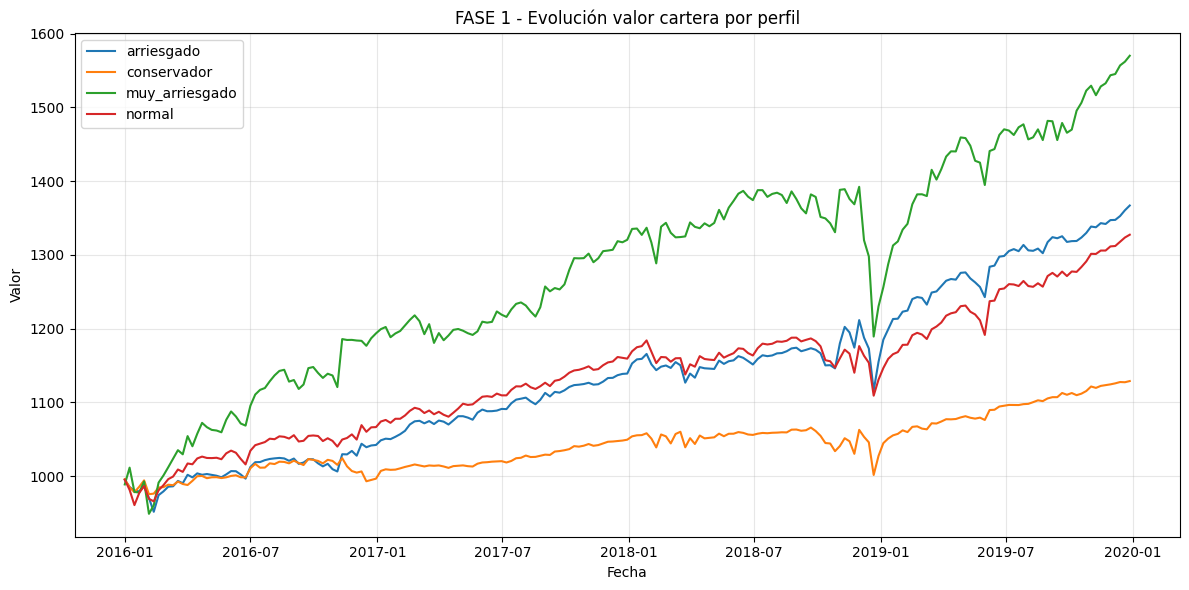

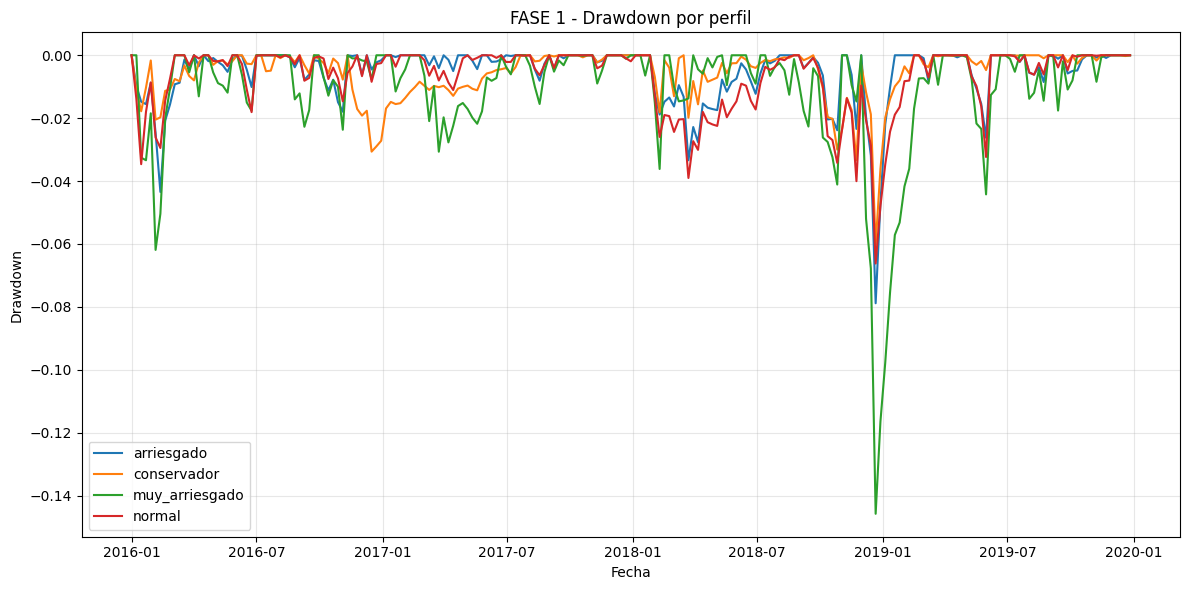

Resumen mejores configs FASE 1:


,perfil_riesgo,riesgo_base,sharpe,cagr,max_drawdown
0,conservador,0.3,0.423309,0.031822,-0.060278
1,normal,0.5,1.065706,0.074628,-0.066220
2,arriesgado,0.7,1.107839,0.082633,-0.078852
3,muy_arriesgado,0.9,1.068856,0.122520,-0.145795


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# COMPARACIÓN DE PERFILES - FASE 1
# ============================================================

# 1) coger el mejor config por perfil en fase 1
mejores_fase1 = (
    finalistas_fase_1
    .sort_values(["perfil_riesgo", "ranking_fase_1"])
    .groupby("perfil_riesgo")
    .head(1)
)

series_mejores = {}

for _, row in mejores_fase1.iterrows():
    perfil = row["perfil_riesgo"]
    config_id = row["config_id"]

    serie = curvas_fase_1[perfil][config_id][0].copy()
    serie.name = perfil
    series_mejores[perfil] = serie

df_curvas = pd.concat(series_mejores.values(), axis=1)
df_curvas = df_curvas.sort_index()

# Base 100
df_base100 = df_curvas.div(df_curvas.iloc[0]).mul(100)

# Drawdown
df_drawdown = df_curvas.div(df_curvas.cummax()).sub(1.0)

figsize = (12, 6)

# -------------------------
# 1) Valor cartera
# -------------------------
plt.figure(figsize=figsize)
for col in df_curvas.columns:
    plt.plot(df_curvas.index, df_curvas[col], label=col)
plt.title("FASE 1 - Evolución valor cartera por perfil")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 2) Drawdown
# -------------------------
plt.figure(figsize=figsize)
for col in df_drawdown.columns:
    plt.plot(df_drawdown.index, df_drawdown[col], label=col)
plt.title("FASE 1 - Drawdown por perfil")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 3) Resumen
# -------------------------
print("Resumen mejores configs FASE 1:")
display(
    mejores_fase1[
        ["perfil_riesgo", "riesgo_base", "sharpe", "cagr", "max_drawdown"]
    ].sort_values("riesgo_base")
)

In [ ]:

print("Resumen agregado FASE 1:")
display(
    resumen_fase_1.sort_values(["perfil_riesgo", "sharpe", "cagr"], ascending=[True, False, False])[
        [
            "perfil_riesgo", "riesgo_base", "config_id", "sharpe", "cagr", "max_drawdown",
            "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
            "tamano_batch", "offset_target_entropy",
            "max_concentracion_total_extra"
        ]
    ].head(25)
)

print("Finalistas de la FASE 1:")
display(
    finalistas_fase_1[[
        "perfil_riesgo", "riesgo_base", "ranking_fase_1", "config_id", "sharpe", "cagr", "max_drawdown",
        "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
        "tamano_batch", "offset_target_entropy", "max_concentracion_total_extra"
    ]].sort_values(["perfil_riesgo", "ranking_fase_1"])
)


Resumen agregado FASE 1:


,perfil_riesgo,riesgo_base,config_id,sharpe,cagr,max_drawdown,gamma,tau,lr_actor,lr_criticos,lr_alpha,tamano_batch,offset_target_entropy,max_concentracion_total_extra
2,muy_arriesgado,0.9,cfg_001,0.349333,0.065994,-0.324881,0.99,0.005,0.0003,0.001,0.001,256,-4.5,5
0,muy_conservador,0.1,cfg_001,0.349333,0.065994,-0.324881,0.99,0.005,0.0003,0.001,0.001,256,-4.5,5
1,normal,0.5,cfg_001,0.349333,0.065994,-0.324881,0.99,0.005,0.0003,0.001,0.001,256,-4.5,5


Finalistas de la FASE 1:


,perfil_riesgo,riesgo_base,ranking_fase_1,config_id,sharpe,cagr,max_drawdown,gamma,tau,lr_actor,lr_criticos,lr_alpha,tamano_batch,offset_target_entropy,max_concentracion_total_extra
2,muy_arriesgado,0.9,1,cfg_001,0.349333,0.065994,-0.324881,0.99,0.005,0.0003,0.001,0.001,256,-4.5,5
0,muy_conservador,0.1,1,cfg_001,0.349333,0.065994,-0.324881,0.99,0.005,0.0003,0.001,0.001,256,-4.5,5
1,normal,0.5,1,cfg_001,0.349333,0.065994,-0.324881,0.99,0.005,0.0003,0.001,0.001,256,-4.5,5



## FASE 2

Cada perfil ya tiene sus **3 mejores finalistas**.  
Ahora cada uno se reentrena a **100k pasos**, manteniendo el mismo perfil de riesgo con el que fue seleccionado.


In [ ]:


def run_finalistas_100k_por_perfil(
    finalistas_df: pd.DataFrame,
    base_config: Dict[str, Any],
    pasos_totales: int = 100_000,
    n_runs: int = 1,
    seed_start: int = 42,
):
    all_logs = []
    resumen_rows = []
    curvas_validation = {}

    for perfil, df_perfil in finalistas_df.groupby("perfil_riesgo", sort=False):
        curvas_validation[perfil] = {}
        print("#" * 100)
        print(f"FASE 2 -> PERFIL: {perfil} | reentrenamiento a {pasos_totales:,} pasos")
        print("#" * 100)

        for _, row in df_perfil.iterrows():
            config_id = f"{perfil}|finalista_{int(row['ranking_fase_1']):02d}"
            curvas_validation[perfil][config_id] = []

            combo = {
                "gamma": row["gamma"],
                "tau": row["tau"],
                "lr_actor": row["lr_actor"],
                "lr_criticos": row["lr_criticos"],
                "lr_alpha": row["lr_alpha"],
                "tamano_batch": int(row["tamano_batch"]),
                "offset_target_entropy": row["offset_target_entropy"],
                "max_concentracion_total_extra": row["max_concentracion_total_extra"],
                "riesgo": float(row["riesgo_base"]),
            }

            print("=" * 80)
            print(f"Entrenando {config_id}")
            print(combo)

            for run_id in range(n_runs):
                cfg = copy.deepcopy(base_config)
                cfg.update(combo)
                cfg["pasos_totales"] = int(pasos_totales)
                cfg["semilla"] = seed_start + run_id
                cfg["tamano_buffer"] = max(int(cfg["tamano_buffer"]), int(pasos_totales))
                cfg["pasos_warmup"] = min(max(2_000, pasos_totales // 10), 10_000)

                experiment_id = f"{config_id}|run={run_id}"

                history, serie_valor_val, metricas_val, agente = train_one_run(
                    config=cfg,
                    datos_estado_train=datos_estado_train,
                    retornos_train=retornos_train,
                    rf_semanal_train=rf_semanal_train,
                    datos_estado_val=datos_estado_val,
                    retornos_val=retornos_val,
                    rf_semanal_val=rf_semanal_val,
                )

                df_run = history_to_long_df(
                    history=history,
                    experiment_id=experiment_id,
                    config_id=config_id,
                    run_id=run_id,
                )

                for k, v in cfg.items():
                    df_run[k] = v
                df_run["perfil_riesgo"] = perfil
                df_run["riesgo_base"] = float(row["riesgo_base"])
                df_run["ranking_fase_1"] = int(row["ranking_fase_1"])

                all_logs.append(df_run)
                curvas_validation[perfil][config_id].append(serie_valor_val)

                row_out = {
                    "experiment_id": experiment_id,
                    "config_id": config_id,
                    "run_id": run_id,
                    "perfil_riesgo": perfil,
                    "riesgo_base": float(row["riesgo_base"]),
                    "ranking_fase_1": int(row["ranking_fase_1"]),
                }
                row_out.update(cfg)
                row_out.update(build_summary_row_train(df_run))
                row_out.update(metricas_val)
                resumen_rows.append(row_out)

                print(
                    f"Sharpe={metricas_val['sharpe']:.4f} | "
                    f"CAGR={metricas_val['cagr']:.4%} | "
                    f"MDD={metricas_val['max_drawdown']:.4%}"
                )

    logs_df = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()
    resumen_df = pd.DataFrame(resumen_rows)

    return logs_df, resumen_df, curvas_validation


In [ ]:

logs_fase_2, resumen_fase_2, curvas_fase_2 = run_finalistas_100k_por_perfil(
    finalistas_df=finalistas_fase_1,
    base_config=base_config,
    pasos_totales=PASOS_FINALISTAS,
    n_runs=1,
    seed_start=SEED_BASE,
)


####################################################################################################
FASE 2 -> PERFIL: muy_conservador | reentrenamiento a 100,000 pasos
####################################################################################################
Entrenando muy_conservador|finalista_01
{'gamma': 0.99, 'tau': 0.005, 'lr_actor': 0.0003, 'lr_criticos': 0.001, 'lr_alpha': 0.001, 'tamano_batch': 256, 'offset_target_entropy': -4.5, 'max_concentracion_total_extra': 5, 'riesgo': 0.1}
[DIAGNÓSTICO INICIAL]
  media:   min=-0.0282  max=0.0543
  log_std: min=-0.0446  max=0.0678
  log_prob: -64.6271  <- debe ser negativo
  entropía: 18.5366  <- debe ser positivo
  accion suma: 1.000000  <- debe ser 1.0
  target_entropy: -58.5000
retorno=-0.031692 | pen_total=+0.010388 | reward=-0.042542 | lambda_dd=0.05 | dd=0.1351 | vol=0.012679 | cash=0.016 | riesgo=0.10
[Paso    1000] reward_media(1000)=-0.006474 | critic1=3.857620 | critic2=2.867500 | actor=-560.643982 | alpha=0.423201 | 

KeyboardInterrupt: 


## FASE 3

Se compara, dentro de cada perfil, cuál de sus 3 finalistas a 100k obtiene el mejor resultado.  
Ese será el **conjunto de hiperparámetros definitivo para ese perfil de riesgo**.


In [ ]:

resumen_fase_2 = resumen_fase_2.sort_values(
    by=["perfil_riesgo", "sharpe", "cagr"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("Ranking FASE 2 (100k) por perfil:")
display(
    resumen_fase_2[[
        "perfil_riesgo", "riesgo_base", "config_id", "sharpe", "cagr", "max_drawdown", "valor_final",
        "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
        "tamano_batch", "offset_target_entropy", "max_concentracion_total_extra"
    ]]
)

idx_mejores = resumen_fase_2.groupby("perfil_riesgo")["sharpe"].idxmax()
mejores_por_perfil = resumen_fase_2.loc[idx_mejores].sort_values("riesgo_base").reset_index(drop=True)

print("Mejor conjunto de hiperparámetros para cada perfil:")
display(
    mejores_por_perfil[[
        "perfil_riesgo", "riesgo_base", "config_id", "sharpe", "cagr", "max_drawdown", "valor_final",
        "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
        "tamano_batch", "reward_scale", "offset_target_entropy", "max_concentracion_total_extra"
    ]]
)



## FASE 4

Se guardan:

- todos los logs de la fase 1,
- el resumen de la fase 1,
- los finalistas de la fase 1,
- los logs de la fase 2,
- el resumen de la fase 2,
- y un **diccionario JSON con la configuración ganadora de cada perfil**.


In [ ]:

out_dir = Path("resultados_hpo_por_perfiles_riesgo")
out_dir.mkdir(parents=True, exist_ok=True)

ruta_logs_fase_1 = out_dir / "fase_1_logs.csv"
ruta_resumen_fase_1 = out_dir / "fase_1_summary.csv"
ruta_finalistas_fase_1 = out_dir / "fase_1_finalistas.csv"
ruta_logs_fase_2 = out_dir / "fase_2_logs_100k.csv"
ruta_resumen_fase_2 = out_dir / "fase_2_summary_100k.csv"
ruta_mejores_por_perfil = out_dir / "mejores_por_perfil.csv"
ruta_parametros_json = out_dir / "parametros_ganadores_por_perfil.json"

logs_fase_1.to_csv(ruta_logs_fase_1, index=False)
resumen_fase_1.to_csv(ruta_resumen_fase_1, index=False)
finalistas_fase_1.to_csv(ruta_finalistas_fase_1, index=False)
logs_fase_2.to_csv(ruta_logs_fase_2, index=False)
resumen_fase_2.to_csv(ruta_resumen_fase_2, index=False)
mejores_por_perfil.to_csv(ruta_mejores_por_perfil, index=False)

param_cols = [
    "riesgo_base",
    "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
    "tamano_batch", "reward_scale", "offset_target_entropy",
    "max_concentracion_total_extra",
]

parametros_ganadores_por_perfil = {}
for _, row in mejores_por_perfil.iterrows():
    perfil = row["perfil_riesgo"]
    parametros_ganadores_por_perfil[perfil] = {
        col: (int(row[col]) if col == "tamano_batch" else float(row[col]))
        for col in param_cols
    }

with open(ruta_parametros_json, "w", encoding="utf-8") as f:
    json.dump(parametros_ganadores_por_perfil, f, ensure_ascii=False, indent=4)

print("Archivos guardados:")
print(ruta_logs_fase_1.resolve())
print(ruta_resumen_fase_1.resolve())
print(ruta_finalistas_fase_1.resolve())
print(ruta_logs_fase_2.resolve())
print(ruta_resumen_fase_2.resolve())
print(ruta_mejores_por_perfil.resolve())
print(ruta_parametros_json.resolve())

print("Diccionario final para usar en el futuro:")
print(json.dumps(parametros_ganadores_por_perfil, ensure_ascii=False, indent=4))



### Uso futuro esperado

Después de ejecutar el notebook, podrás cargar directamente el JSON y usar el mejor conjunto de parámetros según el perfil de riesgo del usuario.

Ejemplo conceptual:

```python
with open("resultados_hpo_por_perfiles_riesgo/parametros_ganadores_por_perfil.json", "r", encoding="utf-8") as f:
    parametros_por_perfil = json.load(f)

perfil = clasificar_perfil_riesgo(score_riesgo_usuario)
params = parametros_por_perfil[perfil]
```
